In [ ]:
from math import log, sqrt, exp, erf
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf
import numpy as np

def ncdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black76_put(F: float, K: float, r: float, sigma: float, T: float) -> float:
    if F <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        raise ValueError("Bad data")

    df = exp(-r * T)
    vsqrtT = sigma * sqrt(T)
    d1 = (log(F / K) + 0.5 * sigma * sigma * T) / vsqrtT
    d2 = d1 - vsqrtT

    return df * (K * ncdf(-d2) - F * ncdf(-d1))

BASE, FUTURES, FT_SCALE, RATE = "^XSP", "ESZ26.CME", 10, "^IRX"
today, expiry = "2025-10-25", "2026-12-18"

today_date = datetime.strptime(today, "%Y-%m-%d").date()
expiry_date = datetime.strptime(expiry, "%Y-%m-%d").date()
days_to_expiry = (expiry_date - today_date).days
T_years = days_to_expiry / 365.0

XSP = yf.Ticker(BASE)
XSP_puts = XSP.option_chain(expiry).puts
XSP_puts["mid"] = (XSP_puts["bid"] + XSP_puts["ask"]) / 2

trading_days = 252
XSP_hist = XSP.history(period=f"{days_to_expiry}d")
XSP_logret = np.log(XSP_hist["Close"]).diff().dropna()
XSP_sigma = XSP_logret.std(ddof=1) * np.sqrt(trading_days)
XSP_spot = XSP_hist["Close"].iloc[-1]
XSP_puts["spot"] = XSP_spot

ESP = yf.Ticker(FUTURES)
ESP_spot = ESP.history(period=f"1d")["Close"].iloc[-1] / FT_SCALE

IRX = yf.Ticker(RATE)
r_annual = IRX.history(period="1d")["Close"].iloc[-1] / 100

In [20]:

XSP_puts["blackPrice"] = XSP_puts.apply(lambda row: black76_put(ESP_spot, row["strike"], r_annual, XSP_sigma, T_years), axis=1)
XSP_puts["goodRatio"] = XSP_puts["blackPrice"] / XSP_puts["mid"]
XSP_puts["strikePct"] = XSP_puts["strike"] / XSP_puts["spot"]

In [ ]:
costAnnual
fairAnnual

/tmp/ipykernel_36881/4775039.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = XSP_puts[0.85 < XSP_puts["strikePct"]][XSP_puts["strikePct"] < 1.15]


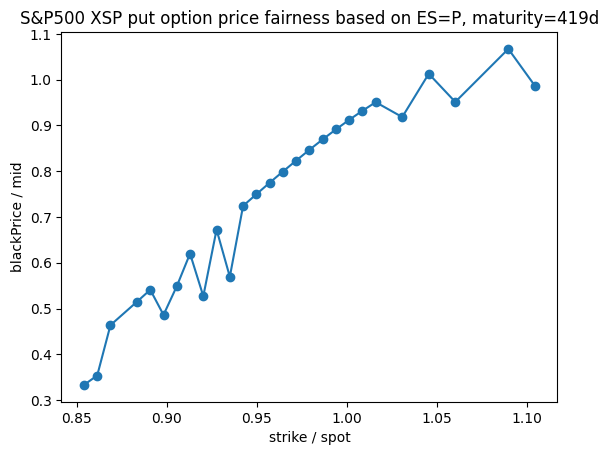

,spot,strike,mid,blackPrice,goodRatio,wasteAbs
30,679.169983,580.0,23.125,7.702331,0.333074,15.422669
31,679.169983,585.0,24.030,8.497842,0.353635,15.532158
32,679.169983,590.0,20.170,9.352056,0.463662,10.817944
33,679.169983,600.0,21.840,11.245016,0.514882,10.594984
34,679.169983,605.0,22.715,12.287752,0.540953,10.427248
35,679.169983,610.0,27.560,13.397156,0.486109,14.162844
36,679.169983,615.0,26.565,14.574962,0.548653,11.990038
37,679.169983,620.0,25.525,15.822790,0.619894,9.702210
38,679.169983,625.0,32.530,17.142132,0.526964,15.387868
39,679.169983,630.0,27.565,18.534354,0.672387,9.030646


In [ ]:


df = XSP_puts[0.85 < XSP_puts["strikePct"]][XSP_puts["strikePct"] < 1.15]

plt.plot(df["strikePct"], df["goodRatio"], marker='o')
plt.xlabel("strike / spot")
plt.ylabel("blackPrice / mid")
plt.title(f"S&P500 XSP put option price fairness based on ES=P, maturity={days_to_expiry}d")
plt.show()

df[["spot", "strike", "mid", "blackPrice", "goodRatio", "wasteAbs"]]